# Pré-entraînement auto-supervisé (SSL) puis fine-tuning

Ici je réutilise l'auto-encodeur autrement : d'abord un pré-entraînement sans labels (juste
reconstruire), puis je récupère l'encodeur pour classer. Je compare deux régimes classiques :

- linear probing : encodeur gelé, on n'entraîne qu'une petite tête
- full fine-tuning : on repart des mêmes poids mais tout le réseau s'adapte

Et à la fin je regarde ce que ça change de faire varier la dimension de l'espace latent.

In [ ]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 123

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

## Données

Découpage 60 / 20 / 20. Le pré-entraînement utilise le train sans labels, la classification
le train avec labels.

In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(X_train.shape, X_val.shape, X_test.shape)

(341, 30) (114, 30) (114, 30)


In [ ]:
Xtr = torch.from_numpy(X_train).float()
Xva = torch.from_numpy(X_val).float()
Xte = torch.from_numpy(X_test).float()
ytr = torch.from_numpy(y_train).long()
yva = torch.from_numpy(y_val).long()
yte = torch.from_numpy(y_test).long()

# sans labels pour le SSL, avec labels pour la classif
pretrain_loader = DataLoader(TensorDataset(Xtr), batch_size=64, shuffle=True)
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(Xte, yte), batch_size=64, shuffle=False)

## Le modèle

Même auto-encodeur qu'au notebook 01, mais avec la dimension latente en paramètre parce que
je vais la faire varier plus loin.

In [ ]:
class Encodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 14),
            nn.LeakyReLU(),
            nn.Linear(14, 6),
            nn.LeakyReLU(),
            nn.Linear(6, latent_dim),
        )
    def forward(self, x):
        return self.net(x)

class Decodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 6),
            nn.LeakyReLU(),
            nn.Linear(6, 14),
            nn.LeakyReLU(),
            nn.Linear(14, 30),
        )
    def forward(self, z):
        return self.net(z)

class AutoEncodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encodeur = Encodeur(latent_dim)
        self.decodeur = Decodeur(latent_dim)
    def forward(self, x):
        return self.decodeur(self.encodeur(x))

class Classifieur(nn.Module):
    def __init__(self, encodeur, latent_dim, freeze):
        super().__init__()
        self.encodeur = encodeur
        if freeze:
            for p in self.encodeur.parameters():
                p.requires_grad = False
        self.tete = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.LeakyReLU(),
            nn.Linear(8, 2),
        )
    def forward(self, x):
        return self.tete(self.encodeur(x))

## Fonctions d'entraînement

Je factorise le pré-entraînement, l'entraînement de la classif et l'évaluation, ça évite de
recopier les mêmes boucles à chaque expérience (et surtout ça m'a évité les bugs d'ordre
d'exécution que j'avais au début).

In [ ]:
def pretrain(latent_dim, epochs=80):
    set_seed()
    ae = AutoEncodeur(latent_dim)
    loss_fn = nn.MSELoss()
    opt = torch.optim.AdamW(ae.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(epochs):
        ae.train()
        for (xb,) in pretrain_loader:
            opt.zero_grad()
            loss = loss_fn(ae(xb), xb)
            loss.backward()
            opt.step()
    return ae

def train_clf(model, epochs=80, verbose=False):
    loss_fn = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if verbose and (epoch + 1) % 20 == 0:
            acc = eval_acc(model, val_loader)
            print("epoch", epoch + 1, "val acc", round(acc, 3))
    return model

def eval_acc(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += len(yb)
    return correct / total

def test_scores(model):
    model.eval()
    yt, yp, pp = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            pp.extend(torch.softmax(logits, dim=1)[:, 1].numpy())
            yp.extend(logits.argmax(dim=1).numpy())
            yt.extend(yb.numpy())
    yt, yp, pp = np.array(yt), np.array(yp), np.array(pp)
    return {"f1": f1_score(yt, yp, average="macro"), "auc": roc_auc_score(yt, pp), "yt": yt, "yp": yp}

## Pré-entraînement (latent = 2)

In [ ]:
ae = pretrain(latent_dim=2)

pre-entrainement fait


## Linear probing

In [ ]:
set_seed()
probe = Classifieur(copy.deepcopy(ae.encodeur), latent_dim=2, freeze=True)
train_clf(probe, verbose=True)

r_probe = test_scores(probe)
print()
print("F1 macro:", round(r_probe["f1"], 3), "| ROC-AUC:", round(r_probe["auc"], 3))
print(classification_report(r_probe["yt"], r_probe["yp"], target_names=data.target_names))

epoch 20 val acc 0.921
epoch 40 val acc 0.93
epoch 60 val acc 0.921
epoch 80 val acc 0.921

F1 macro: 0.953 | ROC-AUC: 0.986
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## Full fine-tuning

On repart des mêmes poids pré-entraînés (deepcopy) mais cette fois rien n'est gelé.

In [ ]:
set_seed()
ft = Classifieur(copy.deepcopy(ae.encodeur), latent_dim=2, freeze=False)
train_clf(ft, verbose=True)

r_ft = test_scores(ft)
print()
print("F1 macro:", round(r_ft["f1"], 3), "| ROC-AUC:", round(r_ft["auc"], 3))
print(confusion_matrix(r_ft["yt"], r_ft["yp"]))

epoch 20 val acc 0.965
epoch 40 val acc 0.974
epoch 60 val acc 0.974
epoch 80 val acc 0.974

F1 macro: 0.981 | ROC-AUC: 0.997
[[41  1]
 [ 1 71]]


## Comparaison des deux régimes

In [ ]:
def n_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("linear probing  -> params entraines:", n_trainable(probe),
      "| F1:", round(r_probe["f1"], 3), "| AUC:", round(r_probe["auc"], 3))
print("full fine-tuning-> params entraines:", n_trainable(ft),
      "| F1:", round(r_ft["f1"], 3), "| AUC:", round(r_ft["auc"], 3))

linear probing  -> params entraines: 42 | F1: 0.953 | AUC: 0.986
full fine-tuning-> params entraines: 580 | F1: 0.981 | AUC: 0.997


## Effet de la dimension de l'espace latent

La dimension 2 est pratique pour visualiser mais c'est un goulot serré pour classer. Je
relance donc tout le pipeline (pré-entraînement + probing + full fine-tuning) pour plusieurs
dimensions latentes et je regarde comment évoluent le F1 et le ROC-AUC sur le test.

In [ ]:
dims = [2, 4, 8, 16, 32]
rows = []
for d in dims:
    ae_d = pretrain(latent_dim=d)

    set_seed()
    p = Classifieur(copy.deepcopy(ae_d.encodeur), latent_dim=d, freeze=True)
    train_clf(p)
    rp = test_scores(p)

    set_seed()
    f = Classifieur(copy.deepcopy(ae_d.encodeur), latent_dim=d, freeze=False)
    train_clf(f)
    rf = test_scores(f)

    rows.append([d, round(rp["auc"], 3), round(rp["f1"], 3), round(rf["auc"], 3), round(rf["f1"], 3)])
    print("latent", d, "ok")

res = pd.DataFrame(rows, columns=["latent_dim", "probe_auc", "probe_f1", "ft_auc", "ft_f1"])
res

latent 2 ok
latent 4 ok
latent 8 ok
latent 16 ok
latent 32 ok


,latent_dim,probe_auc,probe_f1,ft_auc,ft_f1
0,2,0.986,0.953,0.997,0.981
1,4,0.994,0.944,0.989,0.981
2,8,0.994,0.953,0.985,0.972
3,16,0.991,0.915,0.991,0.972
4,32,0.990,0.944,0.996,0.972


FileNotFoundError: [Errno 2] No such file or directory: 'figures/latent_dim_sweep.png'

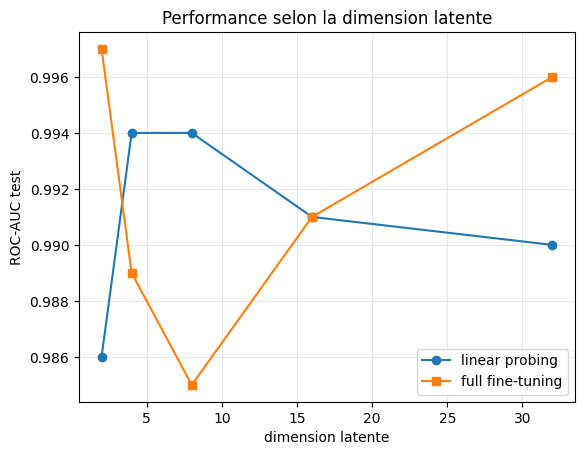

In [ ]:
plt.plot(res["latent_dim"], res["probe_auc"], "o-", label="linear probing")
plt.plot(res["latent_dim"], res["ft_auc"], "s-", label="full fine-tuning")
plt.xlabel("dimension latente"); plt.ylabel("ROC-AUC test"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Performance selon la dimension latente")
plt.savefig("figures/latent_dim_sweep.png", dpi=130, bbox_inches="tight")
plt.show()

## Bilan

Le pré-entraînement donne une représentation déjà utile : même encodeur gelé, une tête
linéaire s'en sort bien. Le full fine-tuning fait un peu mieux, ce qui est attendu vu qu'il a
plus de liberté. Et augmenter la dimension latente aide la classification jusqu'à un certain
point (voir le tableau et la courbe ci-dessus). À comparer aux baselines du notebook 03.